In [ ]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path("..").resolve()))

from _shared.plotting import setup_style, plot_trajectory_ensemble

setup_style()

import time
import matplotlib.pyplot as plt
import numpy as np
import torch

torch.manual_seed(42)
np.random.seed(42)

# experiments/03: Encoder Generalization — Multi-Parameter Birth-Death

**Experimental question:** Can the encoder produce context vectors that the SDE uses to generate correct dynamics for birth-death CRNs it has never seen?

**Setup:** Train on N birth-death CRNs with (k_birth, k_death) sampled from a 2D log-uniform range. Each training item is a different CRN instance. Evaluate on a grid of held-out parameter combinations.

**What success looks like:** For held-out CRNs, the learned drift should be linear with slope -(k_death) and intercept k_birth. The learned diffusion should scale as sqrt(k_birth + k_death * x). Trajectory statistics (mean, variance) should match SSA.

**Controlled variables:** Same encoder architecture, same SDE architecture, same training mode (NLL / teacher forcing), same simulation parameters.

## 1. Experimental Setup

In [2]:
from crn_surrogate.configs.model_config import EncoderConfig, ModelConfig, SDEConfig
from crn_surrogate.configs.training_config import SchedulerType, TrainingConfig, TrainingMode
from crn_surrogate.data.generation.reference_crns import birth_death
from crn_surrogate.evaluation.analytical import birth_death_analytical
from crn_surrogate.encoder.tensor_repr import crn_to_tensor_repr

# Parameter ranges for training data
K_BIRTH_RANGE = (0.5, 10.0)   # log-uniform
K_DEATH_RANGE = (0.1, 2.0)    # log-uniform

# Architecture
encoder_config = EncoderConfig(d_model=32, n_layers=3, use_attention=True)

# All birth-death CRNs have 2 reactions, 1 species
ref_crn = birth_death(k_birth=1.0, k_death=1.0)
sde_config = SDEConfig.from_crn(ref_crn, d_model=32, d_hidden=64, clip_state=True)
model_config = ModelConfig(encoder=encoder_config, sde=sde_config)

print(f"n_species={ref_crn.n_species}, n_reactions={ref_crn.n_reactions}")
print(f"encoder_config: {encoder_config}")
print(f"sde_config:     {sde_config}")

MAX_EPOCHS = 80
train_cfg = TrainingConfig(
    lr=1e-3,
    max_epochs=MAX_EPOCHS,
    batch_size=8,
    n_sde_samples=8,
    n_ssa_samples=16,
    dt=0.2,
    val_every=5,
    grad_clip_norm=1.0,
    scheduler_type=SchedulerType.COSINE,
    training_mode=TrainingMode.TEACHER_FORCING,
    use_wandb=False,
)
print(f"\ntrain_cfg: {train_cfg}")

n_species=1, n_reactions=2
encoder_config: EncoderConfig(d_model=32, n_layers=3, n_propensity_types=7, max_propensity_params=8)
sde_config:     SDEConfig(d_model=32, d_hidden=64, n_noise_channels=2, n_hidden_layers=2, clip_state=True)

train_cfg: TrainingConfig(lr=0.001, max_epochs=80, batch_size=8, dt=0.2, n_ssa_samples=16, scheduler=cosine, training_mode=teacher_forcing, use_wandb=False)


## 2. Training Data

Each training item is a birth-death CRN with independently sampled (k_birth, k_death). For each CRN, we generate M SSA trajectories from x0=0. The key difference from experiments 01/02 is that every item has a different `CRNTensorRepr`, so the encoder sees genuinely different inputs.

In [ ]:
from crn_surrogate.data.dataset import CRNTrajectoryDataset, TrajectoryItem
from crn_surrogate.simulation import GillespieSSA, Trajectory

T_MAX, N_GRID = 15.0, 40
N_WORKERS = 8
M = train_cfg.n_ssa_samples
time_grid = torch.linspace(0.0, T_MAX, N_GRID)
init_state = torch.tensor([0.0])
ssa = GillespieSSA()


def sample_log_uniform(low: float, high: float) -> float:
    return float(np.exp(np.random.uniform(np.log(low), np.log(high))))


def make_dataset(n: int) -> tuple[CRNTrajectoryDataset, list[dict]]:
    """Returns (dataset, param_list) where param_list records k_birth, k_death per item."""
    items = []
    params = []
    for _ in range(n):
        k_b = sample_log_uniform(*K_BIRTH_RANGE)
        k_d = sample_log_uniform(*K_DEATH_RANGE)
        crn = birth_death(k_birth=k_b, k_death=k_d)
        crn_repr = crn_to_tensor_repr(crn)

        trajs = Trajectory.stack_on_grid(
            ssa.simulate_batch(
                stoichiometry=crn.stoichiometry_matrix,
                propensity_fn=crn.evaluate_propensities,
                initial_state=init_state.clone(),
                t_max=T_MAX,
                n_trajectories=M,
                n_workers=N_WORKERS,
            ),
            time_grid,
        )

        items.append(TrajectoryItem(
            crn_repr=crn_repr,
            initial_state=init_state.clone(),
            trajectories=trajs,
            times=time_grid,
        ))
        params.append({"k_birth": k_b, "k_death": k_d})

    return CRNTrajectoryDataset(items), params


train_dataset, train_params = make_dataset(200)
val_dataset, val_params = make_dataset(50)
print(f"Train: {len(train_dataset)} items | Val: {len(val_dataset)} items")

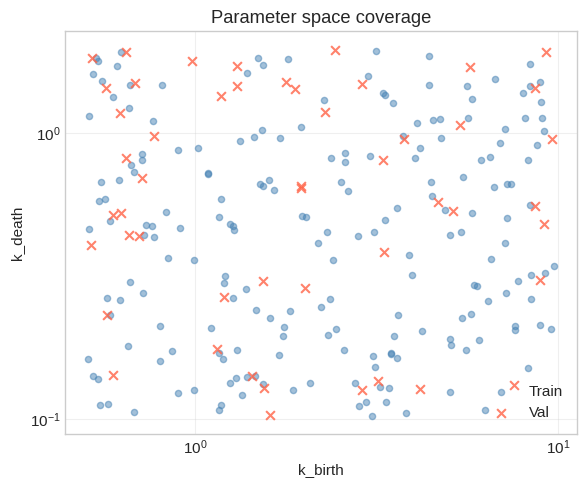

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
train_kb = [p["k_birth"] for p in train_params]
train_kd = [p["k_death"] for p in train_params]
val_kb = [p["k_birth"] for p in val_params]
val_kd = [p["k_death"] for p in val_params]

ax.scatter(train_kb, train_kd, alpha=0.5, s=20, label="Train", color="steelblue")
ax.scatter(val_kb, val_kd, alpha=0.8, s=40, marker="x", label="Val", color="tomato")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel("k_birth")
ax.set_ylabel("k_death")
ax.set_title("Parameter space coverage")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [5]:
# Verify different items have different CRNTensorRepr
repr_0 = train_dataset[0].crn_repr
repr_1 = train_dataset[1].crn_repr
print(f"Item 0 propensity_params: {repr_0.propensity_params}")
print(f"Item 1 propensity_params: {repr_1.propensity_params}")
print(f"Representations identical: {torch.equal(repr_0.propensity_params, repr_1.propensity_params)}")

Item 0 propensity_params: tensor([[1.5355, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [1.7255, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]])
Item 1 propensity_params: tensor([[4.4804, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.6010, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000]])
Representations identical: False


## 3. Training

Single run with attentive encoder and GaussianTransitionNLL (teacher forcing). The dataset now contains 200 different CRNs, so the encoder must produce useful context vectors for the SDE to succeed.

In [6]:
from crn_surrogate.encoder.bipartite_gnn import BipartiteGNNEncoder
from crn_surrogate.simulator.neural_sde import CRNNeuralSDE
from crn_surrogate.training.trainer import Trainer

encoder = BipartiteGNNEncoder(encoder_config)
sde = CRNNeuralSDE(sde_config, n_species=1)

print(f"Encoder parameters: {sum(p.numel() for p in encoder.parameters()):,}")
print(f"SDE parameters:     {sum(p.numel() for p in sde.parameters()):,}")

t0 = time.perf_counter()
result = Trainer(encoder, sde, model_config, train_cfg).train(train_dataset, val_dataset)
elapsed = time.perf_counter() - t0
print(f"\nTraining: {elapsed:.1f}s  ({elapsed / MAX_EPOCHS:.2f}s/epoch)")

Encoder parameters: 19,280
SDE parameters:     50,371


Epoch    1 | train=1.1747 | grad=3.287


Epoch    2 | train=0.6843 | grad=0.419


Epoch    3 | train=0.6551 | grad=0.383


Epoch    4 | train=0.6472 | grad=0.282


...

Epoch   76 | train=0.5849 | grad=0.139


Epoch   77 | train=0.5849 | grad=0.145


Epoch   78 | train=0.5849 | grad=0.149


Epoch   79 | train=0.5849 | grad=0.160


Epoch   80 | train=0.5849 | val=7.6102 | val_nll=0.5137 | grad=0.130

Training: 599.2s  (7.49s/epoch)


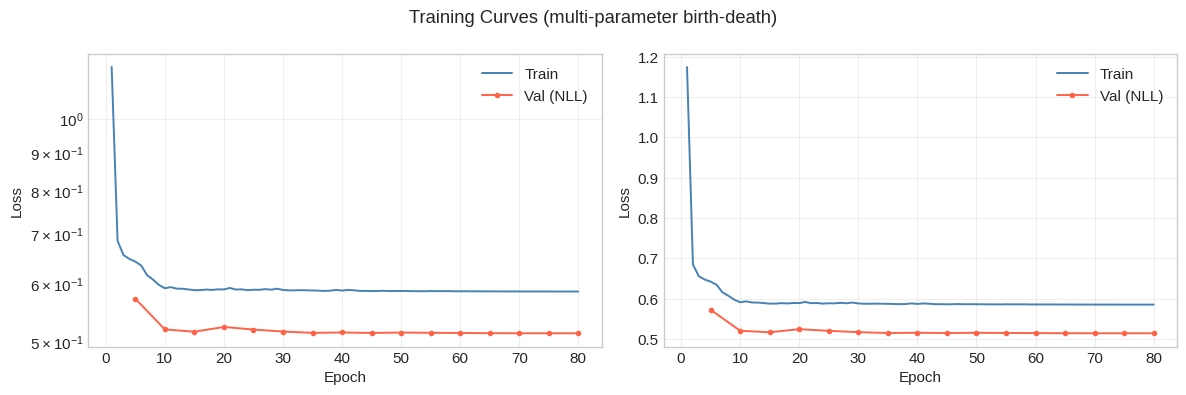

In [7]:
epochs = range(1, MAX_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for ax, yscale in zip(axes, ["log", "linear"]):
    ax.plot(epochs, result.train_losses, color="steelblue", lw=1.4, label="Train")
    if result.val_nll_losses:
        ax.plot(result.val_epochs, result.val_nll_losses,
                color="tomato", lw=1.4, marker="o", ms=3, label="Val (NLL)")
    ax.set_yscale(yscale)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle("Training Curves (multi-parameter birth-death)")
plt.tight_layout()
plt.show()

## 4. Context Vector Analysis

Before looking at dynamics, let's verify the encoder is producing meaningfully different context vectors. We encode a sweep of birth-death CRNs and visualize the context vector space.

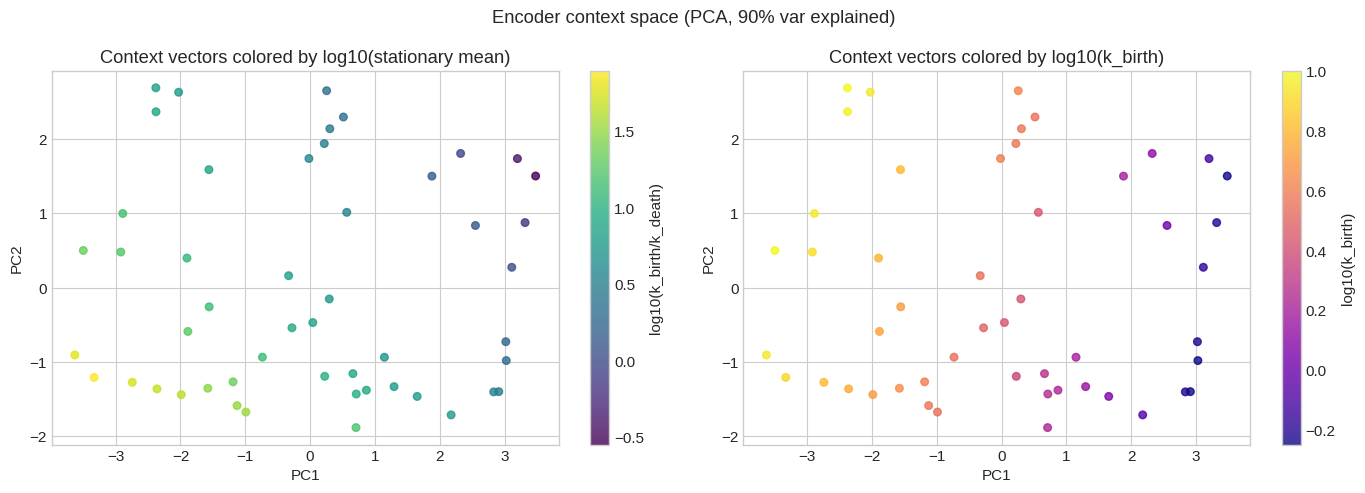

In [9]:
from sklearn.decomposition import PCA

# Grid over parameter space — random pairs to avoid n^2 points
n_grid = 50
kb_vals = np.logspace(np.log10(K_BIRTH_RANGE[0]), np.log10(K_BIRTH_RANGE[1]), n_grid)
kd_vals = np.logspace(np.log10(K_DEATH_RANGE[0]), np.log10(K_DEATH_RANGE[1]), n_grid)
np.random.seed(123)
kb_sweep = np.random.choice(kb_vals, size=n_grid)
kd_sweep = np.random.choice(kd_vals, size=n_grid)

encoder.eval()
ctx_vectors = []
stat_means = []

with torch.no_grad():
    for kb, kd in zip(kb_sweep, kd_sweep):
        crn_i = birth_death(k_birth=float(kb), k_death=float(kd))
        repr_i = crn_to_tensor_repr(crn_i)
        ctx_i = encoder(repr_i, init_state)
        ctx_vectors.append(ctx_i.context_vector.numpy())
        stat_means.append(kb / kd)

ctx_matrix = np.stack(ctx_vectors)
pca = PCA(n_components=2)
ctx_2d = pca.fit_transform(ctx_matrix)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc0 = axes[0].scatter(ctx_2d[:, 0], ctx_2d[:, 1], c=np.log10(stat_means),
                       cmap="viridis", s=30, alpha=0.8)
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].set_title("Context vectors colored by log10(stationary mean)")
plt.colorbar(sc0, ax=axes[0], label="log10(k_birth/k_death)")

sc1 = axes[1].scatter(ctx_2d[:, 0], ctx_2d[:, 1], c=np.log10(kb_sweep),
                       cmap="plasma", s=30, alpha=0.8)
axes[1].set_xlabel("PC1")
axes[1].set_ylabel("PC2")
axes[1].set_title("Context vectors colored by log10(k_birth)")
plt.colorbar(sc1, ax=axes[1], label="log10(k_birth)")

plt.suptitle(f"Encoder context space (PCA, {pca.explained_variance_ratio_[:2].sum():.0%} var explained)")
plt.tight_layout()
plt.show()

## 5. Learned Dynamics on Held-Out CRNs

The money plots. For a selection of held-out (k_birth, k_death) pairs, we compare the learned drift and diffusion against the analytical CLE reference. The analytical drift is f(x) = k_birth - k_death * x, and the diffusion magnitude is |g(x)| = sqrt(k_birth + k_death * x).

In [10]:
from crn_surrogate.evaluation import DynamicsVisualizer

test_cases = [
    {"k_birth": 1.0, "k_death": 0.2, "label": "slow death, mean=5"},
    {"k_birth": 5.0, "k_death": 1.0, "label": "balanced, mean=5"},
    {"k_birth": 8.0, "k_death": 0.5, "label": "high mean=16"},
    {"k_birth": 0.8, "k_death": 1.5, "label": "fast death, mean=0.53"},
    {"k_birth": 3.0, "k_death": 0.3, "label": "slow death, mean=10"},
    {"k_birth": 6.0, "k_death": 2.0, "label": "fast dynamics, mean=3"},
]

for tc in test_cases:
    tc["stat_mean"] = tc["k_birth"] / tc["k_death"]
    print(f"  k_b={tc['k_birth']:.1f}, k_d={tc['k_death']:.1f}  ->  "
          f"stationary mean={tc['stat_mean']:.2f}   ({tc['label']})")

  k_b=1.0, k_d=0.2  ->  stationary mean=5.00   (slow death, mean=5)
  k_b=5.0, k_d=1.0  ->  stationary mean=5.00   (balanced, mean=5)
  k_b=8.0, k_d=0.5  ->  stationary mean=16.00   (high mean=16)
  k_b=0.8, k_d=1.5  ->  stationary mean=0.53   (fast death, mean=0.53)
  k_b=3.0, k_d=0.3  ->  stationary mean=10.00   (slow death, mean=10)
  k_b=6.0, k_d=2.0  ->  stationary mean=3.00   (fast dynamics, mean=3)


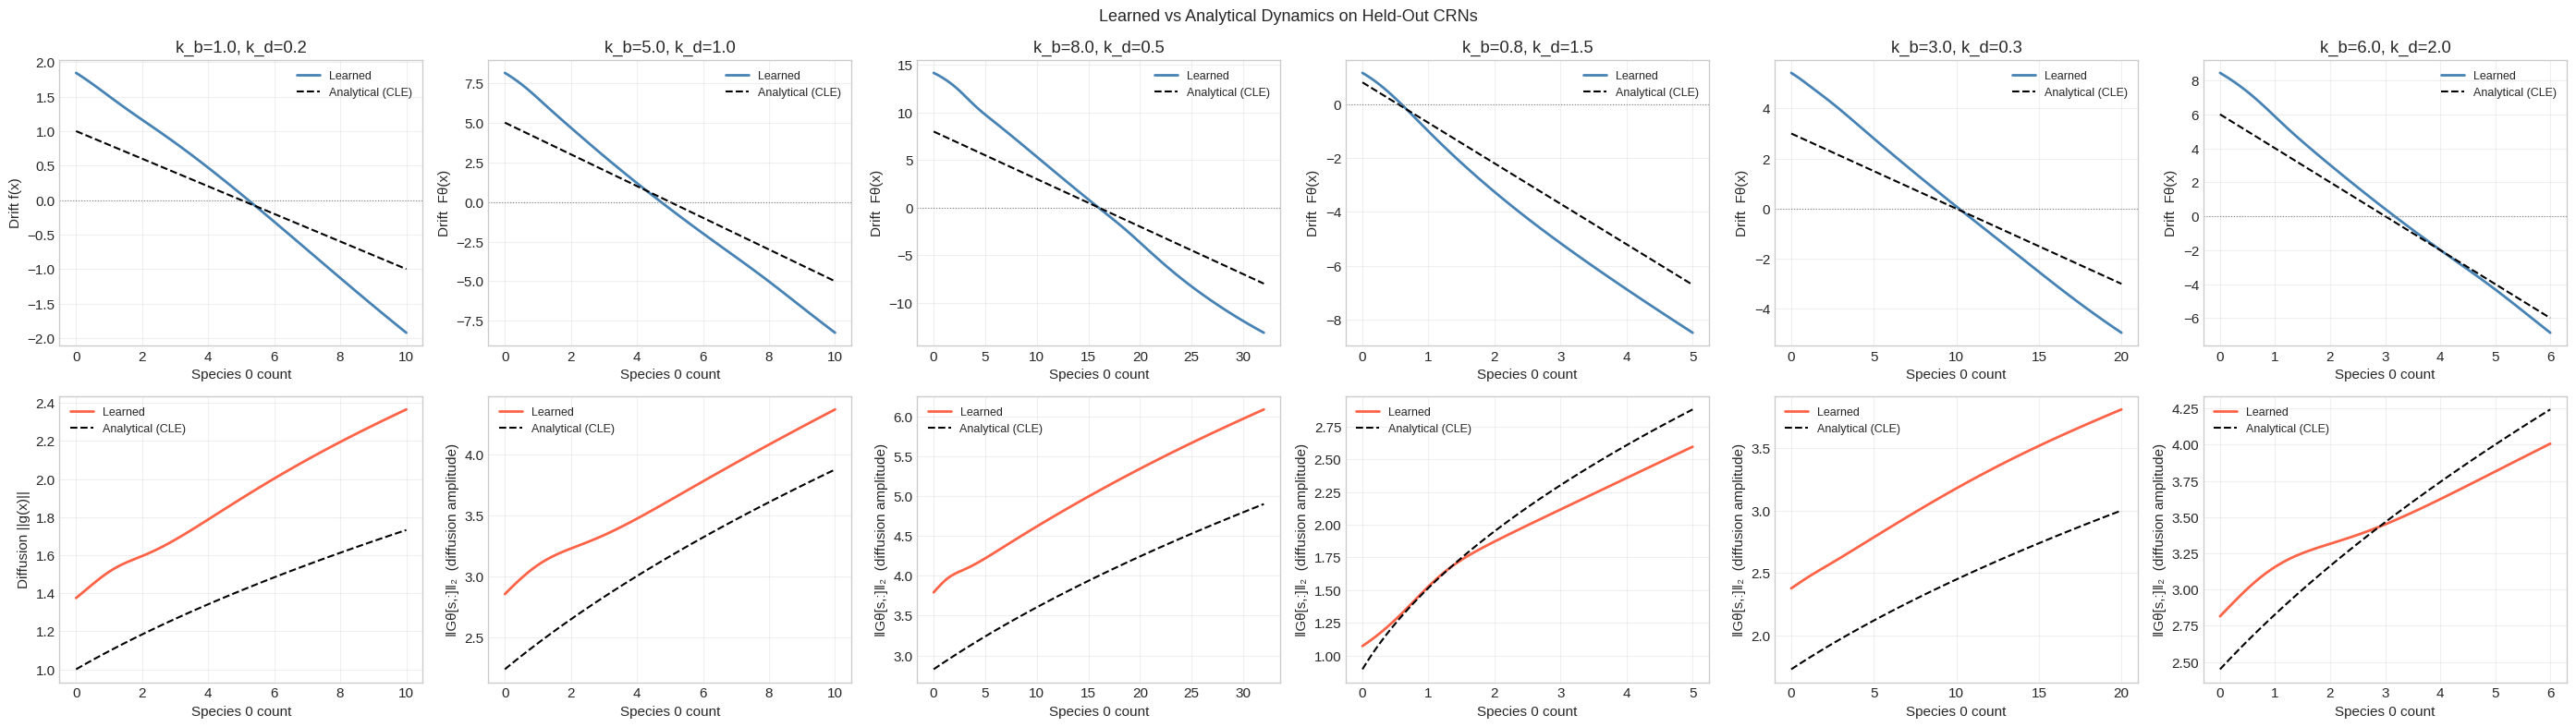

In [11]:
fig, axes = plt.subplots(2, 6, figsize=(28, 8))

for j, tc in enumerate(test_cases):
    crn_j = birth_death(k_birth=tc["k_birth"], k_death=tc["k_death"])
    repr_j = crn_to_tensor_repr(crn_j)
    analytical_j = birth_death_analytical(k_birth=tc["k_birth"], k_death=tc["k_death"])

    x_max = max(2.0 * tc["stat_mean"], 5.0)
    state_range = torch.linspace(0.0, x_max, 80)

    viz = DynamicsVisualizer(encoder, sde, repr_j, init_state)

    viz.plot_drift(state_range, analytical_drift_fn=analytical_j["drift"],
                   label="Learned", color="steelblue", ax=axes[0, j])
    axes[0, j].set_title(f"k_b={tc['k_birth']:.1f}, k_d={tc['k_death']:.1f}")
    if j == 0:
        axes[0, j].set_ylabel("Drift f(x)")

    viz.plot_diffusion(state_range, analytical_diffusion_fn=analytical_j["diffusion"],
                       label="Learned", color="tomato", ax=axes[1, j])
    if j == 0:
        axes[1, j].set_ylabel("Diffusion ||g(x)||")

plt.suptitle("Learned vs Analytical Dynamics on Held-Out CRNs", fontsize=13)
plt.tight_layout()
plt.show()

## 6. Trajectory Quality on Held-Out CRNs

For each held-out CRN, we generate K SDE rollouts and M SSA trajectories, then compare mean and variance trajectories.

In [ ]:
from crn_surrogate.evaluation import ModelEvaluator, TrajectoryComparator

K_EVAL, M_EVAL = 50, 50
eval_times = torch.linspace(0.0, T_MAX, N_GRID)

traj_cases = test_cases[:4]

fig, axes = plt.subplots(len(traj_cases), 3, figsize=(16, 4 * len(traj_cases)))

for row, tc in enumerate(traj_cases):
    crn_j = birth_death(k_birth=tc["k_birth"], k_death=tc["k_death"])
    repr_j = crn_to_tensor_repr(crn_j)
    analytical_j = birth_death_analytical(k_birth=tc["k_birth"], k_death=tc["k_death"])

    ssa_trajs = Trajectory.stack_on_grid(
        ssa.simulate_batch(
            stoichiometry=crn_j.stoichiometry_matrix,
            propensity_fn=crn_j.evaluate_propensities,
            initial_state=init_state.clone(),
            t_max=T_MAX,
            n_trajectories=M_EVAL,
            n_workers=N_WORKERS,
        ),
        eval_times,
    )

    sde_trajs = ModelEvaluator(encoder, sde, sde_config).rollout(
        repr_j, init_state, eval_times, 0.1, n_rollouts=K_EVAL,
    )

    comp = TrajectoryComparator(
        sde_trajs, ssa_trajs, eval_times,
        analytical_mean=analytical_j["stationary_mean"],
        analytical_var=analytical_j["stationary_var"],
    )

    comp.plot_mean_std(sde_label="Neural SDE", sde_color="steelblue", ax=axes[row, 0])
    comp.plot_variance(sde_label="Neural SDE", sde_color="steelblue", ax=axes[row, 1])
    comp.plot_sample_paths(sde_label="Neural SDE", sde_color="steelblue", ax=axes[row, 2])

    axes[row, 0].set_title(f"k_b={tc['k_birth']:.1f}, k_d={tc['k_death']:.1f} | Mean +/- Std")
    axes[row, 1].set_title("Variance")
    axes[row, 2].set_title("Sample Paths")

plt.suptitle("Trajectory Quality on Held-Out CRNs", fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
print(f"{'k_birth':>8} {'k_death':>8} {'stat_mean':>10} {'mean_mse':>10} {'var_mse':>10} {'diffusion_ok':>13}")
print("-" * 70)

for tc in test_cases:
    crn_j = birth_death(k_birth=tc["k_birth"], k_death=tc["k_death"])
    repr_j = crn_to_tensor_repr(crn_j)
    analytical_j = birth_death_analytical(k_birth=tc["k_birth"], k_death=tc["k_death"])

    ssa_trajs = Trajectory.stack_on_grid(
        ssa.simulate_batch(
            stoichiometry=crn_j.stoichiometry_matrix,
            propensity_fn=crn_j.evaluate_propensities,
            initial_state=init_state.clone(),
            t_max=T_MAX,
            n_trajectories=M_EVAL,
            n_workers=N_WORKERS,
        ),
        eval_times,
    )

    sde_trajs = ModelEvaluator(encoder, sde, sde_config).rollout(
        repr_j, init_state, eval_times, 0.1, n_rollouts=K_EVAL,
    )

    comp = TrajectoryComparator(
        sde_trajs, ssa_trajs, eval_times,
        analytical_mean=analytical_j["stationary_mean"],
        analytical_var=analytical_j["stationary_var"],
    )

    m = comp.metrics()
    print(f"{tc['k_birth']:>8.1f} {tc['k_death']:>8.1f} {tc['stat_mean']:>10.2f} "
          f"{m['mean_mse']:>10.4f} {m['var_mse']:>10.4f} "
          f"{'YES' if not m['diffusion_collapsed'] else 'NO':>13}")

## 7. Residual Analysis

Standardized residuals z = (y_{t+1} - mu) / sigma should follow N(0,1) if the model is correct. We check this for a few held-out CRNs.

In [ ]:
from crn_surrogate.evaluation import ResidualAnalyzer

fig, axes = plt.subplots(2, 3, figsize=(16, 8))

for j, tc in enumerate(test_cases[:3]):
    crn_j = birth_death(k_birth=tc["k_birth"], k_death=tc["k_death"])
    repr_j = crn_to_tensor_repr(crn_j)

    ssa_trajs = Trajectory.stack_on_grid(
        ssa.simulate_batch(
            stoichiometry=crn_j.stoichiometry_matrix,
            propensity_fn=crn_j.evaluate_propensities,
            initial_state=init_state.clone(),
            t_max=T_MAX,
            n_trajectories=M_EVAL,
            n_workers=N_WORKERS,
        ),
        eval_times,
    )

    analyzer = ResidualAnalyzer(encoder, sde, repr_j)
    report = analyzer.compute_residuals(ssa_trajs, eval_times, dt=0.2, initial_state=init_state)

    analyzer.plot_histogram(report, ax=axes[0, j],
                            label=f"k_b={tc['k_birth']:.1f}, k_d={tc['k_death']:.1f}")
    analyzer.plot_qq(report, ax=axes[1, j])

    axes[0, j].set_title(f"k_b={tc['k_birth']:.1f}, k_d={tc['k_death']:.1f}")

plt.suptitle("Residual Analysis on Held-Out CRNs", fontsize=13)
plt.tight_layout()
plt.show()

## 8. Interpolation in Parameter Space

A stronger test: pick a line through parameter space and evaluate the model densely along it. If the encoder has learned a smooth mapping from CRN parameters to dynamics, the learned stationary mean should vary smoothly and track the analytical k_birth/k_death.

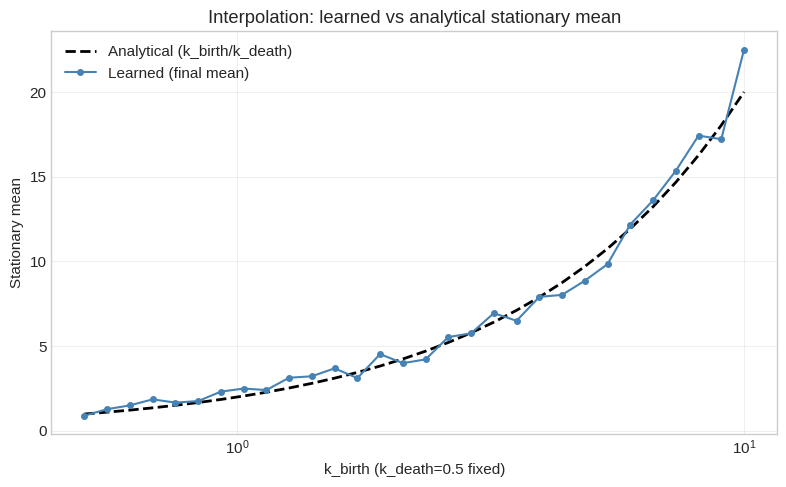

In [15]:
# Fix k_death = 0.5, sweep k_birth from 0.5 to 10.0
k_death_fixed = 0.5
kb_line = np.logspace(np.log10(0.5), np.log10(10.0), 30)

learned_stat_means = []
analytical_stat_means = []

encoder.eval()
sde.eval()

for kb in kb_line:
    crn_i = birth_death(k_birth=float(kb), k_death=k_death_fixed)
    repr_i = crn_to_tensor_repr(crn_i)

    sde_trajs = ModelEvaluator(encoder, sde, sde_config).rollout(
        repr_i, init_state, eval_times, 0.1, n_rollouts=30,
    )  # (K, T, 1)
    final_mean = sde_trajs[:, -1, 0].mean().item()
    learned_stat_means.append(final_mean)
    analytical_stat_means.append(float(kb) / k_death_fixed)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(kb_line, analytical_stat_means, "k--", lw=2, label="Analytical (k_birth/k_death)")
ax.plot(kb_line, learned_stat_means, "o-", color="steelblue", ms=4, lw=1.5, label="Learned (final mean)")
ax.set_xscale("log")
ax.set_xlabel("k_birth (k_death=0.5 fixed)")
ax.set_ylabel("Stationary mean")
ax.set_title("Interpolation: learned vs analytical stationary mean")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Summary

| Metric | Result |
|--------|--------|
| Context vectors vary | (fill from Section 4) |
| Drift shape matches analytical | (fill from Section 5) |
| Diffusion shape matches analytical | (fill from Section 5) |
| Trajectory mean MSE (avg over held-out) | (fill from Section 6) |
| Trajectory var MSE (avg over held-out) | (fill from Section 6) |
| Interpolation curve tracks analytical | (fill from Section 8) |

(Edit this table after running the notebook.)